In [28]:
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (classification_report, confusion_matrix, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, 
                             roc_auc_score, recall_score, cohen_kappa_score)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

# ML Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# DL Models
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2026-01-09 15:57:32.211873: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-09 15:57:35.005130: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 15:57:42.127900: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [5]:
# =====================
# 1. Prepare Data
# =====================
df = pd.read_csv('/workspaces/malnutrition/Dataset/ch.csv')
df = df.drop(columns=['child weight'])

df.head(2)


,child age,diarrhoea,fever,area,child sex,mother education,health insurance,wealth index,status,gandaki,karnali,koshi,madhesh,lumbini,sudurpashchim
0,1.0,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0


In [6]:
# ==============================================================================
# 1. DATA PREPROCESSING AND FEATURE ENGINEERING
# ==============================================================================

def preprocess_data(df, target_column='status'):
    """Enhanced preprocessing with feature engineering"""
    X = df.drop(columns=[target_column]).copy()
    y = df[target_column].copy()
    
    print(f"\nOriginal features: {X.shape[1]}")
    
    # Feature Engineering
    # 1. Interaction features
    X['age_wealth_interaction'] = X['child age'] * X['wealth index']
    X['education_wealth_interaction'] = X['mother education'] * X['wealth index']
    X['age_education_interaction'] = X['child age'] * X['mother education']
    
    # 2. Health risk score
    X['health_risk_score'] = X['diarrhoea'] + X['fever']
    X['has_health_issue'] = (X['health_risk_score'] > 0).astype(int)
    
    # 3. Polynomial features for continuous variables
    X['age_squared'] = X['child age'] ** 2
    X['wealth_squared'] = X['wealth index'] ** 2
    X['education_squared'] = X['mother education'] ** 2
    
    # 4. Regional aggregations
    X['developed_region'] = X['gandaki'] + X['koshi']
    X['underdeveloped_region'] = X['karnali'] + X['sudurpashchim']
    X['central_region'] = X['madhesh'] + X['lumbini']
    
    # 5. Vulnerability score (composite indicator)
    # Normalize to 0-1 scale first
    age_norm = X['child age'] / X['child age'].max()
    wealth_norm = X['wealth index'] / X['wealth index'].max()
    edu_norm = X['mother education'] / X['mother education'].max()
    
    X['vulnerability_score'] = (
        age_norm * 0.2 +  # Younger children
        (1 - wealth_norm) * 0.35 +  # Lower wealth
        (1 - edu_norm) * 0.25 +  # Lower education
        X['health_risk_score'] * 0.2  # Health issues
    )
    
    # 6. Access to healthcare
    X['healthcare_access'] = X['health insurance'] * wealth_norm
    
    # 7. Urban advantage score
    X['urban_advantage'] = X['area'] * wealth_norm * edu_norm
    
    print(f"Features after engineering: {X.shape[1]}")
    print(f"New features added: {X.shape[1] - 15}")
    
    return X, y

def handle_imbalance(X_train, y_train):
    """Handle class imbalance with SMOTE"""
    print(f"\nClass distribution before SMOTE:")
    print(pd.Series(y_train).value_counts())
    
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"\nClass distribution after SMOTE:")
    print(pd.Series(y_resampled).value_counts())
    
    return X_resampled, y_resampled

# ==============================================================================
# 2. MODEL PARAMETERS
# ==============================================================================

# Random Forest
rf_params = {
    'n_estimators': 500,
    'max_depth': 15,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

# XGBoost
xgb_params = {
    'n_estimators': 500,
    'max_depth': 7,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'logloss'
}

# LightGBM
lgbm_params = {
    'n_estimators': 500,
    'max_depth': 7,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# CatBoost
catboost_params = {
    'iterations': 500,
    'depth': 7,
    'learning_rate': 0.05,
    'l2_leaf_reg': 3,
    'random_seed': 42,
    'verbose': False,
    'auto_class_weights': 'Balanced'
}

# Gradient Boosting
gb_params = {
    'n_estimators': 300,
    'max_depth': 7,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'random_state': 42
}

# SVM
svm_params = {
    'C': 10,
    'kernel': 'rbf',
    'gamma': 'scale',
    'class_weight': 'balanced',
    'probability': True,
    'random_state': 42
}

# Logistic Regression
lr_params = {
    'C': 1.0,
    'max_iter': 1000,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

# AdaBoost
ada_params = {
    'n_estimators': 200,
    'learning_rate': 0.5,
    'random_state': 42
}

# ==============================================================================
# 3. TRAINING FUNCTION
# ==============================================================================

def train_and_evaluate(X, y, model_name, model, scale_data=True):
    """Complete training and evaluation pipeline"""
    print(f"\n{'='*70}")
    print(f"Training {model_name}...")
    print(f"{'='*70}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Handle imbalance
    X_train_bal, y_train_bal = handle_imbalance(X_train, y_train)
    
    # Scale features if needed
    if scale_data:
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train_bal)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled = X_train_bal
        X_test_scaled = X_test
    
    # Train model
    model.fit(X_train_scaled, y_train_bal)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Get probability predictions if available
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = y_pred
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Calculate AUC
    try:
        auc = roc_auc_score(y_test, y_pred_proba)
    except:
        auc = 0.0
    
    # Print results
    print(f"\nResults for {model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")
    
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'AUC': auc
    }
    
    return results, model, scaler if scale_data else None

# ==============================================================================
# 4. DEEP LEARNING MODELS
# ==============================================================================

def create_dnn_model(input_dim):
    """Create Deep Neural Network"""
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim,
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(64, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        
        layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    
    return model

def train_dl_model(X, y, model_name='DNN'):
    """Train Deep Learning model"""
    print(f"\n{'='*70}")
    print(f"Training {model_name}...")
    print(f"{'='*70}")
    
    # Split and prepare data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    X_train_bal, y_train_bal = handle_imbalance(X_train, y_train)
    
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_bal)
    X_test_scaled = scaler.transform(X_test)
    
    # Create model
    model = create_dnn_model(X_train_scaled.shape[1])
    
    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=20, 
                               restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, 
                                  patience=10, min_lr=1e-7, verbose=0)
    
    # Train
    history = model.fit(
        X_train_scaled, y_train_bal,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    # Evaluate
    y_pred_proba = model.predict(X_test_scaled, verbose=0).flatten()
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"\nResults for {model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")
    
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'AUC': auc
    }
    
    return results, model, scaler

# ==============================================================================
# 5. MAIN EXECUTION
# ==============================================================================

def main(df):
    """Main execution function"""
    
    print("\n" + "="*70)
    print("MALNUTRITION PREDICTION - MODEL COMPARISON")
    print("="*70)
    
    # Preprocess data
    X, y = preprocess_data(df, target_column='status')
    
    print(f"\nDataset shape: {X.shape}")
    print(f"Target distribution:\n{y.value_counts()}")
    
    # Initialize models
    models_config = {
        'Random Forest': (RandomForestClassifier(**rf_params), False),
        'XGBoost': (XGBClassifier(**xgb_params), False),
        'LightGBM': (LGBMClassifier(**lgbm_params), False),
        'CatBoost': (CatBoostClassifier(**catboost_params), False),
        'Gradient Boosting': (GradientBoostingClassifier(**gb_params), False),
        'SVM': (SVC(**svm_params), True),
        'Logistic Regression': (LogisticRegression(**lr_params), True),
        'AdaBoost': (AdaBoostClassifier(**ada_params), False)
    }
    
    # Train all ML models
    results = []
    trained_models = {}
    
    for name, (model, scale) in models_config.items():
        try:
            result, trained_model, scaler = train_and_evaluate(X, y, name, model, scale)
            results.append(result)
            trained_models[name] = (trained_model, scaler)
        except Exception as e:
            print(f"\nError training {name}: {str(e)}")
    
    # Train DNN
    try:
        dnn_result, dnn_model, dnn_scaler = train_dl_model(X, y, 'Deep Neural Network')
        results.append(dnn_result)
        trained_models['Deep Neural Network'] = (dnn_model, dnn_scaler)
    except Exception as e:
        print(f"\nError training DNN: {str(e)}")
    
    # Create results dataframe
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False)
    
    # Display results
    print("\n" + "="*70)
    print("FINAL RESULTS - ALL MODELS")
    print("="*70)
    print(results_df.to_string(index=False))
    
    # Best model
    best_model_name = results_df.iloc[0]['Model']
    best_accuracy = results_df.iloc[0]['Accuracy']
    
    print(f"\n{'='*70}")
    print(f"BEST MODEL: {best_model_name}")
    print(f"ACCURACY: {best_accuracy:.4f}")
    print(f"{'='*70}")
    
    return results_df, trained_models, X, y


In [4]:

# ==============================================================================
# 6. USAGE EXAMPLE
# ==============================================================================

if __name__ == "__main__":

    
    # For testing, create sample data structure
    print("\nTo use this script:")
    print("1. Load your data: df = pd.read_csv('your_file.csv')")
    print("2. Run: results_df, models, X, y = main(df)")
    print("\nThe script will train all 9 models and display results.")
    
    # Uncomment below to run with your data:
    results_df, trained_models, X, y = main(df)


To use this script:
1. Load your data: df = pd.read_csv('your_file.csv')
2. Run: results_df, models, X, y = main(df)

The script will train all 9 models and display results.

MALNUTRITION PREDICTION - MODEL COMPARISON

Original features: 15
Features after engineering: 29
New features added: 14

Dataset shape: (6552, 29)
Target distribution:
status
0    3535
1    3017
Name: count, dtype: int64

Training Random Forest...

Class distribution before SMOTE:
status
0    2828
1    2413
Name: count, dtype: int64

Class distribution after SMOTE:
status
0    2828
1    2828
Name: count, dtype: int64

Results for Random Forest:
  Accuracy:  0.7147
  Precision: 0.7142
  Recall:    0.7147
  F1 Score:  0.7142
  AUC:       0.7850

Training XGBoost...

Class distribution before SMOTE:
status
0    2828
1    2413
Name: count, dtype: int64

Class distribution after SMOTE:
status
0    2828
1    2828
Name: count, dtype: int64

Results for XGBoost:
  Accuracy:  0.7353
  Precision: 0.7349
  Recall:    0.7353

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Results for AdaBoost:
  Accuracy:  0.7117
  Precision: 0.7185
  Recall:    0.7117
  F1 Score:  0.7119
  AUC:       0.7935

Training Deep Neural Network...

Class distribution before SMOTE:
status
0    2828
1    2413
Name: count, dtype: int64

Class distribution after SMOTE:
status
0    2828
1    2828
Name: count, dtype: int64


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-09 15:58:18.894454: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



Results for Deep Neural Network:
  Accuracy:  0.7475
  Precision: 0.7475
  Recall:    0.7475
  F1 Score:  0.7463
  AUC:       0.8327

FINAL RESULTS - ALL MODELS
              Model  Accuracy  Precision   Recall  F1_Score      AUC
Deep Neural Network  0.747521   0.747536 0.747521  0.746289 0.832676
           CatBoost  0.742944   0.742529 0.742944  0.742507 0.818279
                SVM  0.736079   0.735684 0.736079  0.735742 0.801765
            XGBoost  0.735317   0.734931 0.735317  0.735000 0.804074
           LightGBM  0.728452   0.727991 0.728452  0.727537 0.806280
  Gradient Boosting  0.723112   0.722904 0.723112  0.722987 0.802861
Logistic Regression  0.717010   0.719885 0.717010  0.717446 0.790972
      Random Forest  0.714722   0.714163 0.714722  0.714159 0.784963
           AdaBoost  0.711670   0.718548 0.711670  0.711892 0.793503

BEST MODEL: Deep Neural Network
ACCURACY: 0.7475


In [ ]:

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

## Base Model

In [ ]:
# =====================
# 2. Base Model with SMOTE outside pipeline
# =====================
base_lr = LogisticRegression(solver='liblinear', random_state=42)
base_lr.fit(X_train_sm, y_train_sm)

y_pred_base = base_lr.predict(X_test)
y_proba_base = base_lr.predict_proba(X_test)[:, 1]
y_train_pred_base = base_lr.predict(X_train_sm)

# Evaluation
print(confusion_matrix(y_test, y_pred_base))
print("------------------------------------------------------")
print(classification_report(y_test, y_pred_base, digits=3))
print("------------------------------------------------------")
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

[[405 302]
 [227 377]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.641     0.573     0.605       707
           1      0.555     0.624     0.588       604

    accuracy                          0.596      1311
   macro avg      0.598     0.599     0.596      1311
weighted avg      0.601     0.596     0.597      1311

------------------------------------------------------
Test Avg Precision: 0.584
Test AUC: 0.626
Test Cohen's Kappa: 0.195
Training recall: 0.620


## Tuned Model

In [ ]:
# Define pipeline
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

# Define full parameter grid (including solver and penalty)
param_grid = [
    {
        'lr__penalty': ['l1'],
        'lr__solver': ['liblinear', 'saga'],
        'lr__C': [0.01, 0.1, 1, 10]
    },
    {
        'lr__penalty': ['l2'],
        'lr__solver': ['lbfgs', 'liblinear', 'saga'],
        'lr__C': [0.01, 0.1, 1, 10]
    },
    {
        'lr__penalty': ['elasticnet'],
        'lr__solver': ['saga'],
        'lr__C': [0.01, 0.1, 1, 10],
        'lr__l1_ratio': [0.1, 0.5, 0.9]  # Only relevant for elasticnet
    }
]

# Run GridSearchCV
grid_lr = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
,
    verbose=2,
    n_jobs=-1
)

# Fit the model
grid_lr.fit(X_train, y_train)

# Predict and evaluate
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
y_proba_tune = best_lr.predict_proba(X_test)[:, 1]

# Scores for tuned model
print("Best Parameters:", grid_lr.best_params_)
print('------------------------------------------------------')
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, digits=3))

y_train_pred_lr = best_lr.predict(X_train)

print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_lr):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_lr):.3f}")

Fitting 15 folds for each of 32 candidates, totalling 480 fits


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf in

[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.2s
[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.2s
[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.1s
[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.1s


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf in

[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.1s
[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.1s
[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.1s
[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.1s
[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.1s
[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.1s


...

[CV] END ..........lr__C=10, lr__penalty=l1, lr__solver=saga; total time=  10.0s


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END ..........lr__C=10, lr__penalty=l1, lr__solver=saga; total time=  10.1s


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END ..........lr__C=10, lr__penalty=l1, lr__solver=saga; total time=   9.7s


### 95% CI on Recall

Recall 95% CI: (0.707, 0.778)


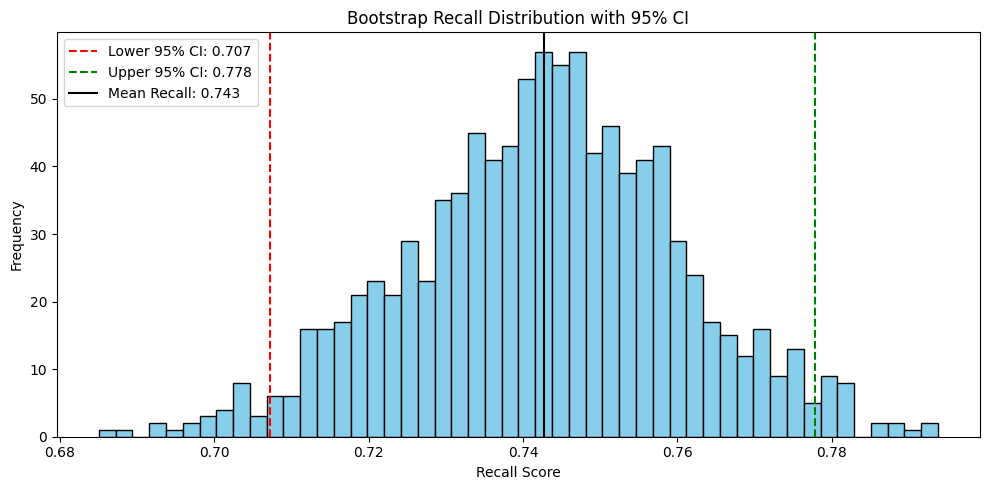

In [6]:
def bootstrap_ci_recall_distribution(y_true, y_pred_func, X, n_bootstraps=1000, alpha=0.95):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = recall_score(y_true.iloc[indices], y_pred_func(X.iloc[indices]))
        bootstrapped_scores.append(score)
    sorted_scores = np.sort(bootstrapped_scores)
    lower = np.percentile(sorted_scores, ((1-alpha)/2)*100)
    upper = np.percentile(sorted_scores, (alpha + (1-alpha)/2)*100)
    return bootstrapped_scores, lower, upper

# scores
recall_scores, lower_ci, upper_ci = bootstrap_ci_recall_distribution(
    y_test.reset_index(drop=True), 
    base_lr.predict,  #calculated on base model because base model is better than tuned model
    X_test.reset_index(drop=True)
)

print(f"Recall 95% CI: ({lower_ci:.3f}, {upper_ci:.3f})")

# plot
plt.figure(figsize=(10, 5))
plt.hist(recall_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower_ci, color='red', linestyle='--', label=f"Lower 95% CI: {lower_ci:.3f}")
plt.axvline(upper_ci, color='green', linestyle='--', label=f"Upper 95% CI: {upper_ci:.3f}")
plt.axvline(np.mean(recall_scores), color='black', linestyle='-', label=f"Mean Recall: {np.mean(recall_scores):.3f}")
plt.title("Bootstrap Recall Distribution with 95% CI")
plt.xlabel("Recall Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Feature importance

Logistic Regression naturally supports feature importance because it is a linear model. The model coefficients (coef_) can be interpreted as the impact of each feature on the log-odds of the positive class.

             Feature      Base
0          child age  1.188898
1       child weight -1.998074
2          diarrhoea  0.012491
3              fever -0.137660
4               area -0.165644
5          child sex  0.466503
6   mother education -0.129420
7   health insurance  0.214744
8       wealth index -0.085455
9            gandaki -0.189544
10           karnali  0.239506
11             koshi -0.227049
12           madhesh  0.246789
13           lumbini -0.011794
14     sudurpashchim  0.052835


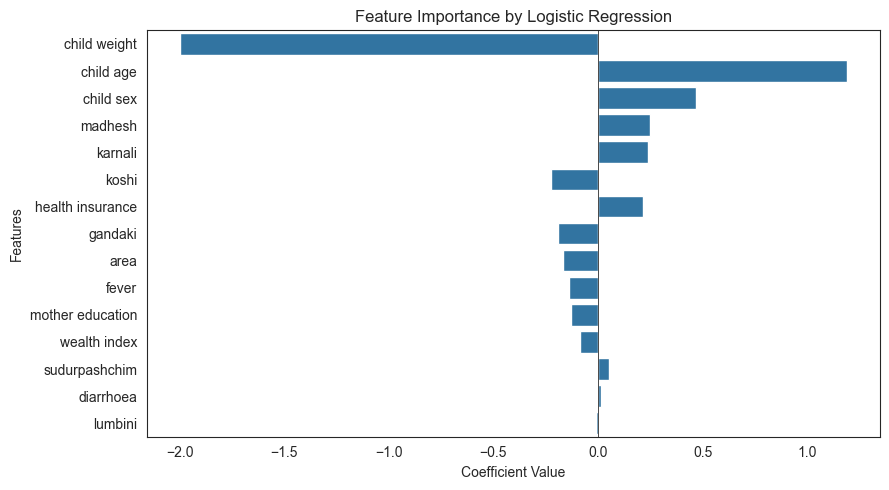

In [41]:
# Extract coefficients for base model only
coef_base = base_lr.coef_[0]

# Build DataFrame for base model only
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Base': coef_base
})

# Take top 5 features based on absolute base coefficients
top_features = importance_df.loc[np.abs(importance_df['Base']).argsort()]['Feature'].tolist()
filtered_df = importance_df[importance_df['Feature'].isin(top_features)]

# Sort features by absolute coefficient value
feature_order = (filtered_df.set_index('Feature')['Base']
                 .abs()
                 .sort_values(ascending=False)
                 .index)

print(filtered_df)

# ====================
# Plot
# ====================

sns.set_style("white")
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=filtered_df,
    y='Feature',
    x='Base',
    order=feature_order,
)

# # Coefficient labels
# for container in ax.containers:
#     ax.bar_label(container, fmt="%.3f", label_type="edge", fontsize=9, padding=3)

# Add titles and labels
plt.title('Feature Importance by Logistic Regression')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.ylabel('Features')
plt.yticks() 
plt.xticks()
plt.tight_layout()
plt.show()


### Average precision

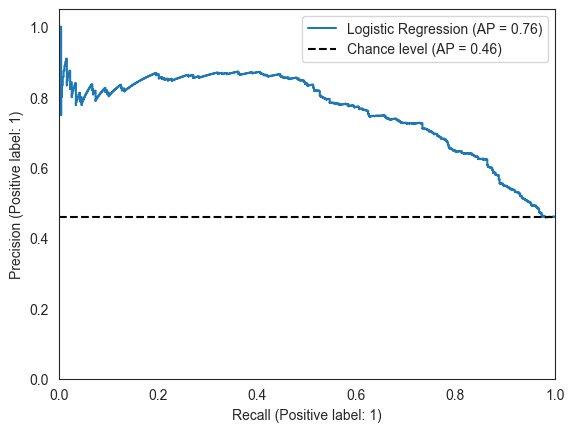

In [10]:
display = PrecisionRecallDisplay.from_estimator(
    base_lr,            # Trained model
    X_test,              # Test features
    y_test,              # True labels
    name="Logistic Regression",          # Name for legend
    plot_chance_level=True  # Automatically plots chance-level baseline
)

# display.ax_.set_title("Precision-Recall curve")
display.ax_.legend(loc='upper right')
display.ax_.set_xlim([0.0, 1.0])
display.ax_.set_ylim([0.0, 1.05])
plt.show()

### Additional

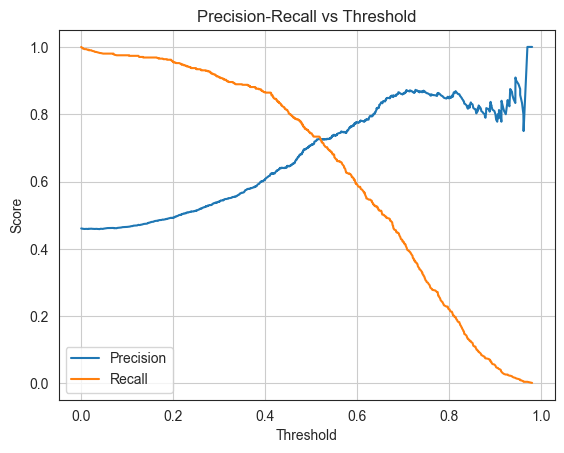

In [11]:
y_proba_tune = base_lr.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Apply custom threshold
y_proba_custom = (y_proba_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_proba_custom, digits = 3)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0      0.820     0.521     0.637       707
           1      0.607     0.866     0.714       604

    accuracy                          0.680      1311
   macro avg      0.713     0.693     0.675      1311
weighted avg      0.722     0.680     0.672      1311


